# Geocodificação
É um processo de transformar nomes de lugares ou endereços de um conjunto de dados para coordenadas. 

Vamos utilizar a biblioteca geopy https://geopy.readthedocs.io/en/stable/.

Existem diversos serviços de geocodificação, vamos utilizar o Open Street Map

In [80]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [81]:
caminho = r"C:\Users\glima\OneDrive\Documentos\geral\CursoPyGeoDev\projeto\script\MOD06_dados_e_scripts\MOD06_dados_e_script\parques_sp.csv"
dados = pd.read_csv(caminho, sep=';')

In [82]:
dados

,name,address
0,Parque Villa-Lobos,"Avenida Prof. Fonseca Rodrigues, 2001 - Alto d..."
1,Parque Tenente Siqueira Campos - Trianon,"Rua Peixoto Gomide, 949 - Cerqueira César, São..."
2,Parque Aclimação,"Rua Muniz de Sousa, 1.119 - Aclimação, São Pau..."
3,Parque Jardim da Luz,"Praça da Luz, s/n - Bom Retiro, São Paulo - SP"
4,Parque Independência,"Avenida Nazaré, s/n - Ipiranga, São Paulo - SP"
5,Parque Alfredo Volpi,"Rua Engenheiro Oscar Americano, 480 - Morumbi,..."
6,Parque Ecológico do Tietê,"Rodovia Parque, 8055 - Vila Santo Henrique, Sã..."


In [83]:
from geopandas.tools import geocode

In [84]:
dados_geo = geocode(dados['address'], provider='nominatim', user_agent='geodev_06')

In [85]:
dados_geo

,geometry,address
0,POINT (-46.7272 -23.54594),"Orquidário Ruth Cardoso, 2001, Avenida Profess..."
1,POINT (-46.6571 -23.5609),"Rua Peixoto Gomide, Cerqueira César, Jardim Pa..."
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ..."
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P..."
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã..."
5,POINT (-46.70407 -23.59171),"Rua Engenheiro Oscar Americano, 840, Avenida E..."
6,POINT (-48.52872 -20.70991),"Rodovia Brigadeiro Faria Lima, Loteamento Sant..."


In [86]:
type(dados_geo)

geopandas.geodataframe.GeoDataFrame

In [87]:
dados_geo = dados_geo.rename(columns={'address':'endereco'})

In [88]:
dados_geo

,geometry,endereco
0,POINT (-46.7272 -23.54594),"Orquidário Ruth Cardoso, 2001, Avenida Profess..."
1,POINT (-46.6571 -23.5609),"Rua Peixoto Gomide, Cerqueira César, Jardim Pa..."
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ..."
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P..."
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã..."
5,POINT (-46.70407 -23.59171),"Rua Engenheiro Oscar Americano, 840, Avenida E..."
6,POINT (-48.52872 -20.70991),"Rodovia Brigadeiro Faria Lima, Loteamento Sant..."


In [89]:
dados_geo_join = dados_geo.join(dados)
dados_geo_join

,geometry,endereco,name,address
0,POINT (-46.7272 -23.54594),"Orquidário Ruth Cardoso, 2001, Avenida Profess...",Parque Villa-Lobos,"Avenida Prof. Fonseca Rodrigues, 2001 - Alto d..."
1,POINT (-46.6571 -23.5609),"Rua Peixoto Gomide, Cerqueira César, Jardim Pa...",Parque Tenente Siqueira Campos - Trianon,"Rua Peixoto Gomide, 949 - Cerqueira César, São..."
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ...",Parque Aclimação,"Rua Muniz de Sousa, 1.119 - Aclimação, São Pau..."
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P...",Parque Jardim da Luz,"Praça da Luz, s/n - Bom Retiro, São Paulo - SP"
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã...",Parque Independência,"Avenida Nazaré, s/n - Ipiranga, São Paulo - SP"
5,POINT (-46.70407 -23.59171),"Rua Engenheiro Oscar Americano, 840, Avenida E...",Parque Alfredo Volpi,"Rua Engenheiro Oscar Americano, 480 - Morumbi,..."
6,POINT (-48.52872 -20.70991),"Rodovia Brigadeiro Faria Lima, Loteamento Sant...",Parque Ecológico do Tietê,"Rodovia Parque, 8055 - Vila Santo Henrique, Sã..."


In [90]:
# Salvar esse arquivo 
local_saida = r"C:\Users\glima\OneDrive\Documentos\geral\CursoPyGeoDev\projeto\outputs\dados_parque_sp.gpkg"
dados_geo_join.to_file(local_saida)

# Plotando o mapa

In [91]:
import folium

In [92]:
dados_geo_join.head() #ver 5 primeiras linhas

,geometry,endereco,name,address
0,POINT (-46.7272 -23.54594),"Orquidário Ruth Cardoso, 2001, Avenida Profess...",Parque Villa-Lobos,"Avenida Prof. Fonseca Rodrigues, 2001 - Alto d..."
1,POINT (-46.6571 -23.5609),"Rua Peixoto Gomide, Cerqueira César, Jardim Pa...",Parque Tenente Siqueira Campos - Trianon,"Rua Peixoto Gomide, 949 - Cerqueira César, São..."
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ...",Parque Aclimação,"Rua Muniz de Sousa, 1.119 - Aclimação, São Pau..."
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P...",Parque Jardim da Luz,"Praça da Luz, s/n - Bom Retiro, São Paulo - SP"
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã...",Parque Independência,"Avenida Nazaré, s/n - Ipiranga, São Paulo - SP"


In [93]:
dados_geo_join.tail() #ver 5 últimas linhas

,geometry,endereco,name,address
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ...",Parque Aclimação,"Rua Muniz de Sousa, 1.119 - Aclimação, São Pau..."
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P...",Parque Jardim da Luz,"Praça da Luz, s/n - Bom Retiro, São Paulo - SP"
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã...",Parque Independência,"Avenida Nazaré, s/n - Ipiranga, São Paulo - SP"
5,POINT (-46.70407 -23.59171),"Rua Engenheiro Oscar Americano, 840, Avenida E...",Parque Alfredo Volpi,"Rua Engenheiro Oscar Americano, 480 - Morumbi,..."
6,POINT (-48.52872 -20.70991),"Rodovia Brigadeiro Faria Lima, Loteamento Sant...",Parque Ecológico do Tietê,"Rodovia Parque, 8055 - Vila Santo Henrique, Sã..."


In [94]:
# Point(x, y) Longitude, Latitude
# Longitude
dados_geo_join['geometry'].x #identificar x-longitude na geometria

0   -46.727204
1   -46.657096
2   -46.623944
3   -46.636650
4   -46.609270
5   -46.704069
6   -48.528722
dtype: float64

In [95]:
# Latitude
dados_geo_join['geometry'].y #identificar y-Latitude na geometria

0   -23.545940
1   -23.560898
2   -23.562107
3   -23.534214
4   -23.601655
5   -23.591714
6   -20.709914
dtype: float64

In [96]:
dados_geo_join['Longitude'] = dados_geo_join['geometry'].x
dados_geo_join['Latitude'] = dados_geo_join['geometry'].y

In [97]:
dados_geo_join.head()

,geometry,endereco,name,address,Longitude,Latitude
0,POINT (-46.7272 -23.54594),"Orquidário Ruth Cardoso, 2001, Avenida Profess...",Parque Villa-Lobos,"Avenida Prof. Fonseca Rodrigues, 2001 - Alto d...",-46.727204,-23.545940
1,POINT (-46.6571 -23.5609),"Rua Peixoto Gomide, Cerqueira César, Jardim Pa...",Parque Tenente Siqueira Campos - Trianon,"Rua Peixoto Gomide, 949 - Cerqueira César, São...",-46.657096,-23.560898
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ...",Parque Aclimação,"Rua Muniz de Sousa, 1.119 - Aclimação, São Pau...",-46.623944,-23.562107
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P...",Parque Jardim da Luz,"Praça da Luz, s/n - Bom Retiro, São Paulo - SP",-46.636650,-23.534214
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã...",Parque Independência,"Avenida Nazaré, s/n - Ipiranga, São Paulo - SP",-46.609270,-23.601655


In [98]:
# location = [latitude, longitude]
m = folium.Map(location=[-23.54, -46.72], tiles='openstreetmap', zoom_start=10)

for i, row in dados_geo_join.iterrows(): #for pq queremos q o dado seja lido de um em um para serem plotados os marcadores
    folium.Marker([row['geometry'].y, row['geometry'].x], popup=("Local: " + row['name'])).add_to(m) #aqui é primeiro lat dps long
# popup diz o que queremos q apareça quando clicamos no marker

m

# Pontos dentro de um Polígono

In [99]:
from shapely.geometry import Point, Polygon, MultiPolygon

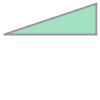

In [100]:
triangulo = Polygon([(1,2), (4,2), (4,3)])
triangulo

In [101]:
ponto1 = triangulo.centroid
ponto2 = Point(0,1)

In [102]:
ponto1.within(triangulo) #descobrir se ponto está dentro ou não do polígono

True

In [103]:
ponto2.within(triangulo) #descobrir se ponto está dentro ou não do polígono

False

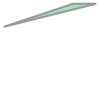

In [104]:
triangulo2 = Polygon([(1,2), (5,3), (4,3)])
triangulo2

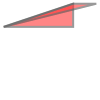

In [105]:
MultiPolygon([triangulo, triangulo2])

In [106]:
triangulo.intersects(triangulo2)  #descobrir se o polígono 1 faz intersecção com triângulo 2

True

In [107]:
import geopandas as gpd

In [108]:
dados = gpd.read_file(r"C:\Users\glima\OneDrive\Documentos\geral\CursoPyGeoDev\projeto\inputs\BR_Municipios_2024(1)\BR_Municipios_2024.shp")
dados.head()

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
0,2504108,Carrapateira,250015,Cajazeiras,2504,Sousa - Cajazeiras,25,Paraíba,PB,2,Nordeste,NE,None,None,59.070,"POLYGON ((-38.33672 -6.99279, -38.33653 -6.993..."
1,1718451,Pugmil,170003,Paraíso do Tocantins,1701,Palmas,17,Tocantins,TO,1,Norte,N,None,None,401.174,"POLYGON ((-48.91085 -10.53824, -48.911 -10.538..."
2,2104206,Fortuna,210016,Presidente Dutra,2104,Presidente Dutra,21,Maranhão,MA,2,Nordeste,NE,None,None,835.668,"POLYGON ((-43.95962 -5.49793, -43.96181 -5.497..."
3,5219902,São Francisco de Goiás,520002,Anápolis,5201,Goiânia,52,Goiás,GO,5,Centro-oeste,CO,None,None,416.535,"POLYGON ((-49.29477 -16.00852, -49.29484 -16.0..."
4,2708600,São Miguel dos Campos,270004,São Miguel dos Campos,2701,Maceió,27,Alagoas,AL,2,Nordeste,NE,None,None,335.679,"POLYGON ((-36.0739 -9.70094, -36.07339 -9.7008..."


In [109]:
dados = dados.loc[dados.SIGLA_UF == 'SP']
dados.head()

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
17,3513009,Cotia,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,Sudeste,SE,3550308,São Paulo/SP,323.994,"POLYGON ((-46.91759 -23.65551, -46.91764 -23.6..."
20,3532827,Nova Campina,350004,Itapeva,3502,Sorocaba,35,São Paulo,SP,3,Sudeste,SE,None,None,385.375,"POLYGON ((-48.89989 -24.10036, -48.87064 -24.1..."
21,3502507,Aparecida,350052,Guaratinguetá,3511,São José dos Campos,35,São Paulo,SP,3,Sudeste,SE,3518404,Guaratinguetá/SP,120.890,"POLYGON ((-45.21167 -22.8313, -45.21076 -22.83..."
33,3543303,Ribeirão Pires,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,Sudeste,SE,3550308,São Paulo/SP,98.972,"POLYGON ((-46.39477 -23.6375, -46.39463 -23.63..."
42,3542008,Quintana,350013,Marília,3504,Marília,35,São Paulo,SP,3,Sudeste,SE,None,None,318.937,"POLYGON ((-50.28246 -22.08134, -50.28251 -22.0..."


In [110]:
dados_sp = dados.copy()
dados_sp.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [111]:
dados_geo_join.crs 

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [112]:
dados_geo_join = dados_geo_join.to_crs(epsg=4674)

In [113]:
dados_geo_join.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [114]:
dados_geo_join.crs == dados_sp.crs

True

<Axes: >

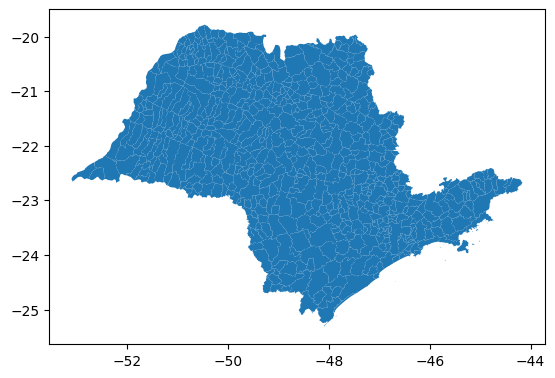

In [115]:
dados_sp.plot()

In [116]:
mun_sp = dados_sp.loc[dados_sp['NM_MUN'] == 'São Paulo']
mun_sp.reset_index(drop=True, inplace=True)
mun_sp

,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIA,NM_REGIA,SIGLA_RG,CD_CONCU,NM_CONCU,AREA_KM2,geometry
0,3550308,São Paulo,350001,São Paulo,3501,São Paulo,35,São Paulo,SP,3,Sudeste,SE,3550308,São Paulo/SP,1521.202,"POLYGON ((-46.61631 -23.87255, -46.61632 -23.8..."


<Axes: >

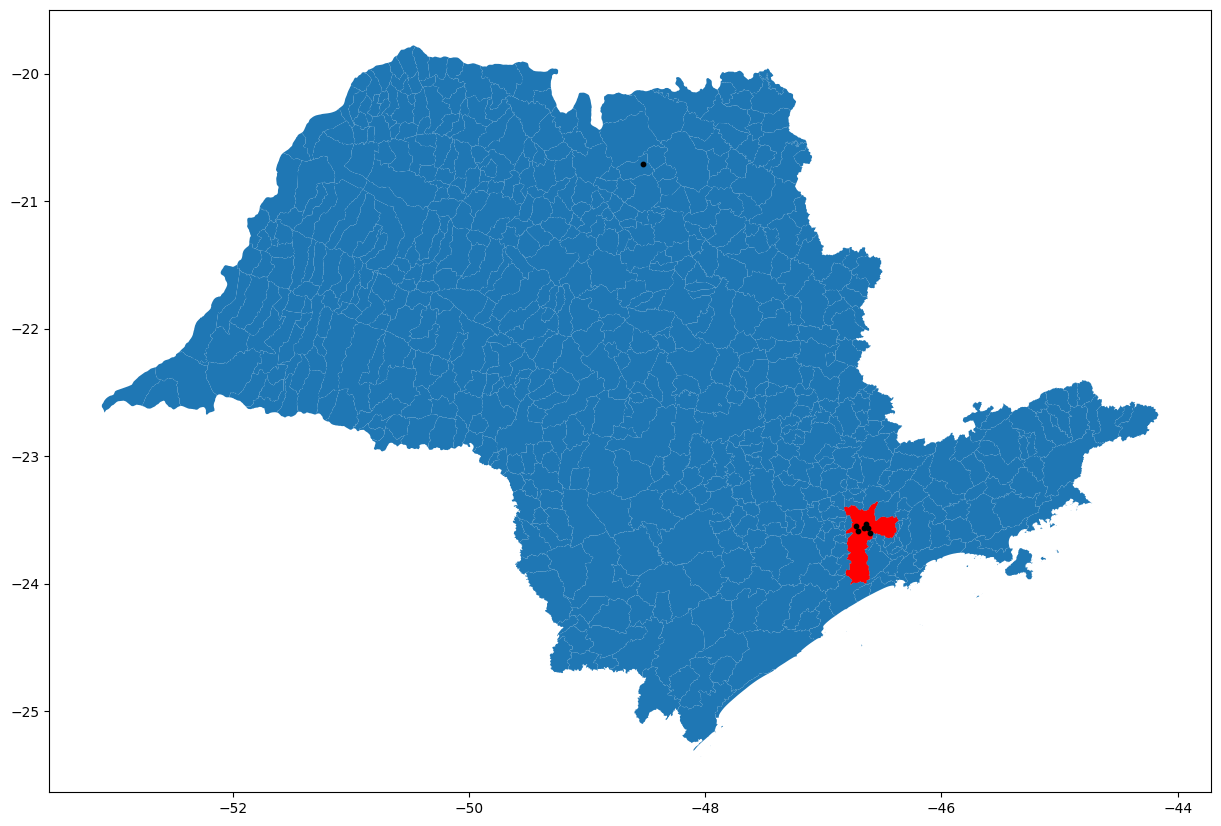

In [117]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,15))

dados_sp.plot(ax=ax)
mun_sp.plot(ax=ax, facecolor='red')

dados_geo_join.plot(ax=ax, color='black', markersize=10)

In [118]:
from shapely import speedups
speedups.enabled

True

In [119]:
mascara_local = dados_geo_join.within(mun_sp.at[0,'geometry'])
print(mascara_local)

0     True
1     True
2     True
3     True
4     True
5     True
6    False
dtype: bool


# Análise de vizinho mais próximo

In [120]:
from shapely.geometry import Point, MultiPoint
from shapely.ops import nearest_points

In [121]:
ponto_origem = Point(2, 3)

ponto1 = Point(0,1)
ponto2 = Point(3,2)
ponto3 = Point(4,5)

In [122]:
destino = MultiPoint([ponto1, ponto2, ponto3])
print(destino)

MULTIPOINT ((0 1), (3 2), (4 5))


In [123]:
vizinho_proximo = nearest_points(ponto_origem, destino)

In [124]:
vizinho_proximo

(<POINT (2 3)>, <POINT (3 2)>)

In [125]:
# o índice 1 retorna o ponto mais próximo de todos, um ponto intermediário
print(vizinho_proximo[1])

POINT (3 2)


In [126]:
import geopandas as gpd

In [127]:
ponto = Point(-46.63, -23.52)

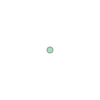

In [128]:
ponto

In [129]:
import pandas as pd
df = pd.DataFrame({
    'Central_Point':'São Paulo',
    'geometry':['POINT(-46.63 -23.52)']
})
df

,Central_Point,geometry
0,São Paulo,POINT(-46.63 -23.52)


In [130]:
type(df)

pandas.core.frame.DataFrame

In [131]:
from shapely import wkt

In [132]:
df['geometry'] = df['geometry'].apply(wkt.loads)

In [133]:
df

,Central_Point,geometry
0,São Paulo,POINT (-46.63 -23.52)


In [134]:
gdf = gpd.GeoDataFrame(df, geometry='geometry')

In [135]:
gdf

,Central_Point,geometry
0,São Paulo,POINT (-46.63 -23.52)


In [136]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

In [137]:
dados_geo_join.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [138]:
from pyproj import CRS

gdf.crs = CRS.from_epsg(4674)

In [139]:
gdf.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [140]:
dados_geo_join

,geometry,endereco,name,address,Longitude,Latitude
0,POINT (-46.7272 -23.54594),"Orquidário Ruth Cardoso, 2001, Avenida Profess...",Parque Villa-Lobos,"Avenida Prof. Fonseca Rodrigues, 2001 - Alto d...",-46.727204,-23.545940
1,POINT (-46.6571 -23.5609),"Rua Peixoto Gomide, Cerqueira César, Jardim Pa...",Parque Tenente Siqueira Campos - Trianon,"Rua Peixoto Gomide, 949 - Cerqueira César, São...",-46.657096,-23.560898
2,POINT (-46.62394 -23.56211),"Rua Muniz de Souza, Aclimação, Liberdade, São ...",Parque Aclimação,"Rua Muniz de Sousa, 1.119 - Aclimação, São Pau...",-46.623944,-23.562107
3,POINT (-46.63665 -23.53421),"Praça da Luz, Bairro da Luz, Bom Retiro, São P...",Parque Jardim da Luz,"Praça da Luz, s/n - Bom Retiro, São Paulo - SP",-46.636650,-23.534214
4,POINT (-46.60927 -23.60165),"Avenida Nazaré, Vila Dom Pedro I, Ipiranga, Sã...",Parque Independência,"Avenida Nazaré, s/n - Ipiranga, São Paulo - SP",-46.609270,-23.601655
5,POINT (-46.70407 -23.59171),"Rua Engenheiro Oscar Americano, 840, Avenida E...",Parque Alfredo Volpi,"Rua Engenheiro Oscar Americano, 480 - Morumbi,...",-46.704069,-23.591714
6,POINT (-48.52872 -20.70991),"Rodovia Brigadeiro Faria Lima, Loteamento Sant...",Parque Ecológico do Tietê,"Rodovia Parque, 8055 - Vila Santo Henrique, Sã...",-48.528722,-20.709914


In [144]:
data_union = dados_geo_join.union_all()
print(data_union)

MULTIPOINT ((-48.5287218 -20.7099144), (-46.7272044 -23.5459397), (-46.704069 -23.591714), (-46.6570958 -23.5608979), (-46.63665 -23.5342137), (-46.6239435 -23.5621073), (-46.6092697 -23.6016547))


In [145]:
ponto_proximo = nearest_points(gdf['geometry'][0], data_union)
print(ponto_proximo)

(<POINT (-46.63 -23.52)>, <POINT (-46.637 -23.534)>)


In [146]:
print(ponto_proximo[1])

POINT (-46.63665 -23.5342137)
